--- Loading MNIST Dataset ---
--- Training SVM (RBF Kernel) ---
--- Evaluating Model ---

✅ Overall Accuracy: 95.30%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       296
           1       0.99      0.99      0.99       338
           2       0.95      0.92      0.94       300
           3       0.94      0.94      0.94       306
           4       0.95      0.97      0.96       292
           5       0.93      0.92      0.93       270
           6       0.96      0.96      0.96       295
           7       0.92      0.99      0.95       313
           8       0.95      0.91      0.93       292
           9       0.96      0.94      0.95       298

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



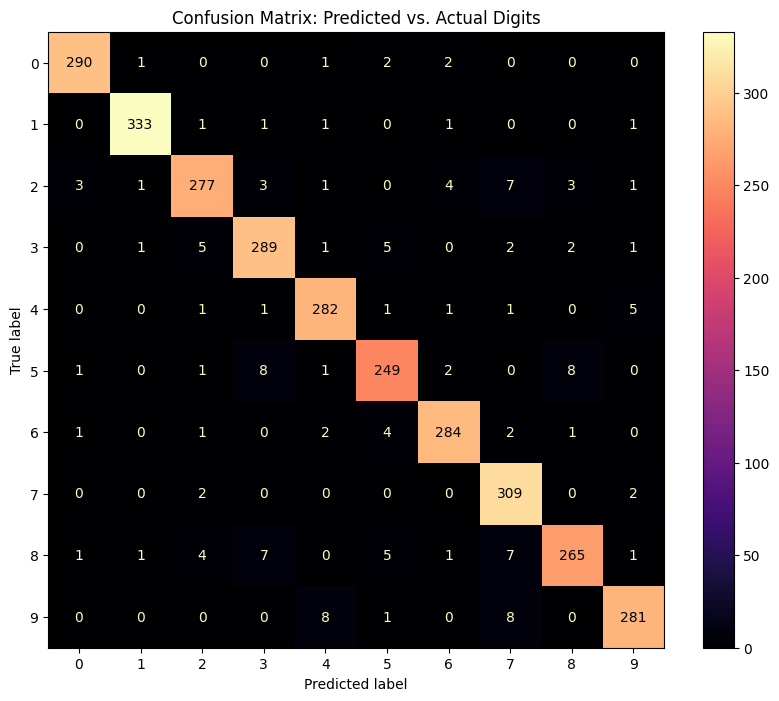

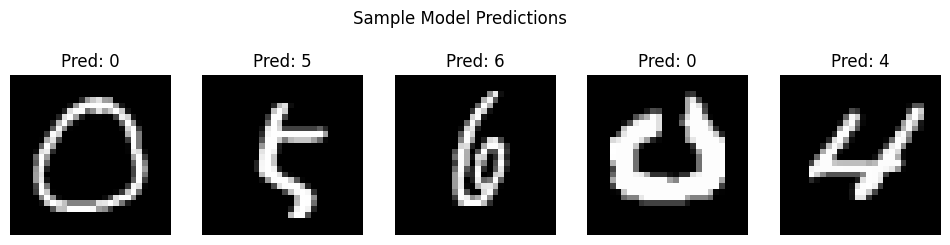

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Load Data
print("--- Loading MNIST Dataset ---")
# as_frame=False ensures we get NumPy arrays directly
X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)

# 2. Preprocessing & Subset Selection
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=12000, test_size=3000, random_state=42, stratify=y
)

# It ensures all pixel features (0-255) are treated equally.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Initialization & Training
# Using RBF (Radial Basis Function) kernel for non-linear boundaries.
# C=5 is a common regularization strength to prevent overfitting.
print("--- Training SVM (RBF Kernel) ---")
svm_model = SVC(kernel='rbf', C=5, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

# 4. Predictions
print("--- Evaluating Model ---")
y_pred = svm_model.predict(X_test_scaled)

# 5. Output Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Overall Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Visualization: Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='magma')
plt.title("Confusion Matrix: Predicted vs. Actual Digits")
plt.show()

# 7. Visualization: Sample Predictions
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    # Reshape the 1D array back to 28x28 for display
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}")
    ax.axis('off')
plt.suptitle("Sample Model Predictions")
plt.show()

Number of Support Vectors found: 2633


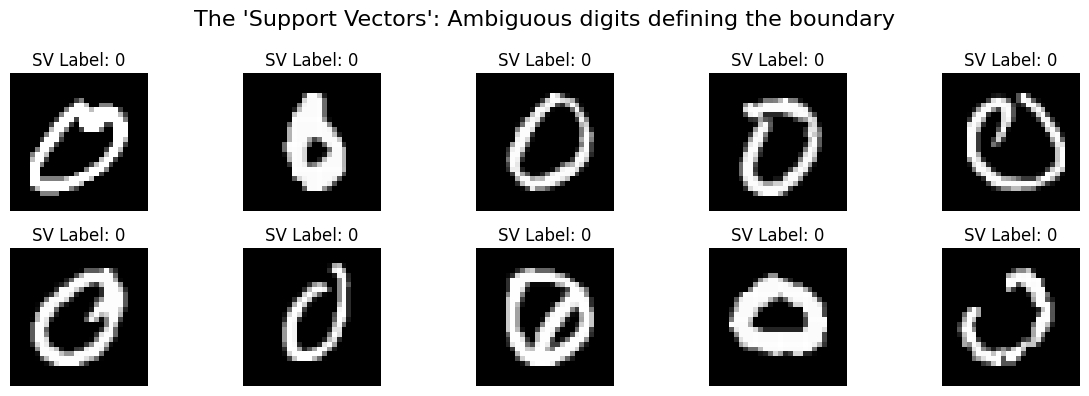

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Setup (using a smaller set for visualization speed)
X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=5000, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Train the model
svm_model = SVC(kernel='rbf', C=5)
svm_model.fit(X_train_scaled, y_train)

# 3. Extract Support Vectors
# svm_model.support_ gives the indices of the support vectors in the training set
sv_indices = svm_model.support_
support_vectors = X_train[sv_indices]
support_labels = y_train[sv_indices]

print(f"Number of Support Vectors found: {len(sv_indices)}")

# 4. Plot the first 10 Support Vectors
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Support vectors are often the 'messy' versions of digits
    plt.imshow(support_vectors[i].reshape(28, 28), cmap='gray')
    plt.title(f"SV Label: {support_labels[i]}")
    plt.axis('off')

plt.suptitle("The 'Support Vectors': Ambiguous digits defining the boundary", fontsize=16)
plt.tight_layout()
plt.show()